In [94]:
# imports & configs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH = 'data/cellvoltages_2026-03-03-21-21-48.csv'
N_CELLS = 84

lsu_colors = ["#4E2A84", "#FDD023","#7F857765","#000000"]  # purple, gold, gray, black
sns.set_theme(style='darkgrid') 
sns.set_palette(sns.color_palette(lsu_colors))
plt.rcParams['figure.figsize'] = (14, 4)

In [95]:
# Clean Dataframe
df = pd.read_csv(PATH)
df.coloumns = df.columns.str.strip()

DROP_COLS = ([f'Cell Resistance {i}' for i in range(1, N_CELLS + 1)] + 
             [f'Open Cell Voltage {i}' for i in range(1, N_CELLS + 1)]) # Impedance Analysis TBA

CV_COLS = [f'Cell Voltage {i}' for i in range(1, N_CELLS + 1)] # Cell Voltage Columns

df = df.drop(columns=DROP_COLS)
df = df.dropna(axis=1, how='all') #Delete BMS trailing comma
df.columns = df.columns.str.strip()

df['Time'] = pd.to_datetime(df['Time'].str.replace(r'\s+CST\s+', ' ', regex=True), 
                             format='%a %b %d %H:%M:%S %Y')

df['elapsed_s'] = (df['Time'] - df['Time'].iloc[0]).dt.total_seconds()

print(df.isnull().sum().sum(), 'total missing values')

0 total missing values


C:\Users\randl\AppData\Local\Temp\ipykernel_12008\3797976050.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.coloumns = df.columns.str.strip()


In [96]:
# Pack Overview
print(f'Duration: {df["elapsed_s"].max() / 60:.1f} min')
print(df.shape)
df.head()

Duration: 14.0 min
(1807, 100)


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Cell Voltage 76,Cell Voltage 77,Cell Voltage 78,Cell Voltage 79,Cell Voltage 80,Cell Voltage 81,Cell Voltage 82,Cell Voltage 83,Cell Voltage 84,elapsed_s
0,2026-03-03 21:21:53,50.0,296.9,0.2,6,198,14,3.5380,9,3.5056,...,3.5372,3.5356,3.5363,3.5349,3.5366,3.5339,3.5360,3.5349,3.5334,0.0
1,2026-03-03 21:21:54,50.0,296.8,0.0,6,198,14,3.5381,9,3.5055,...,3.5372,3.5356,3.5363,3.5349,3.5366,3.5339,3.5360,3.5349,3.5334,1.0
2,2026-03-03 21:21:54,50.0,296.8,-0.3,6,198,14,3.5381,9,3.5055,...,3.5371,3.5356,3.5363,3.5348,3.5367,3.5339,3.5360,3.5350,3.5333,1.0
3,2026-03-03 21:21:54,50.0,296.8,-0.3,6,198,14,3.5380,9,3.5055,...,3.5372,3.5356,3.5363,3.5348,3.5367,3.5339,3.5361,3.5349,3.5334,1.0
4,2026-03-03 21:21:55,50.0,296.8,-0.3,6,198,14,3.5381,9,3.5055,...,3.5371,3.5357,3.5363,3.5349,3.5368,3.5339,3.5360,3.5349,3.5333,2.0


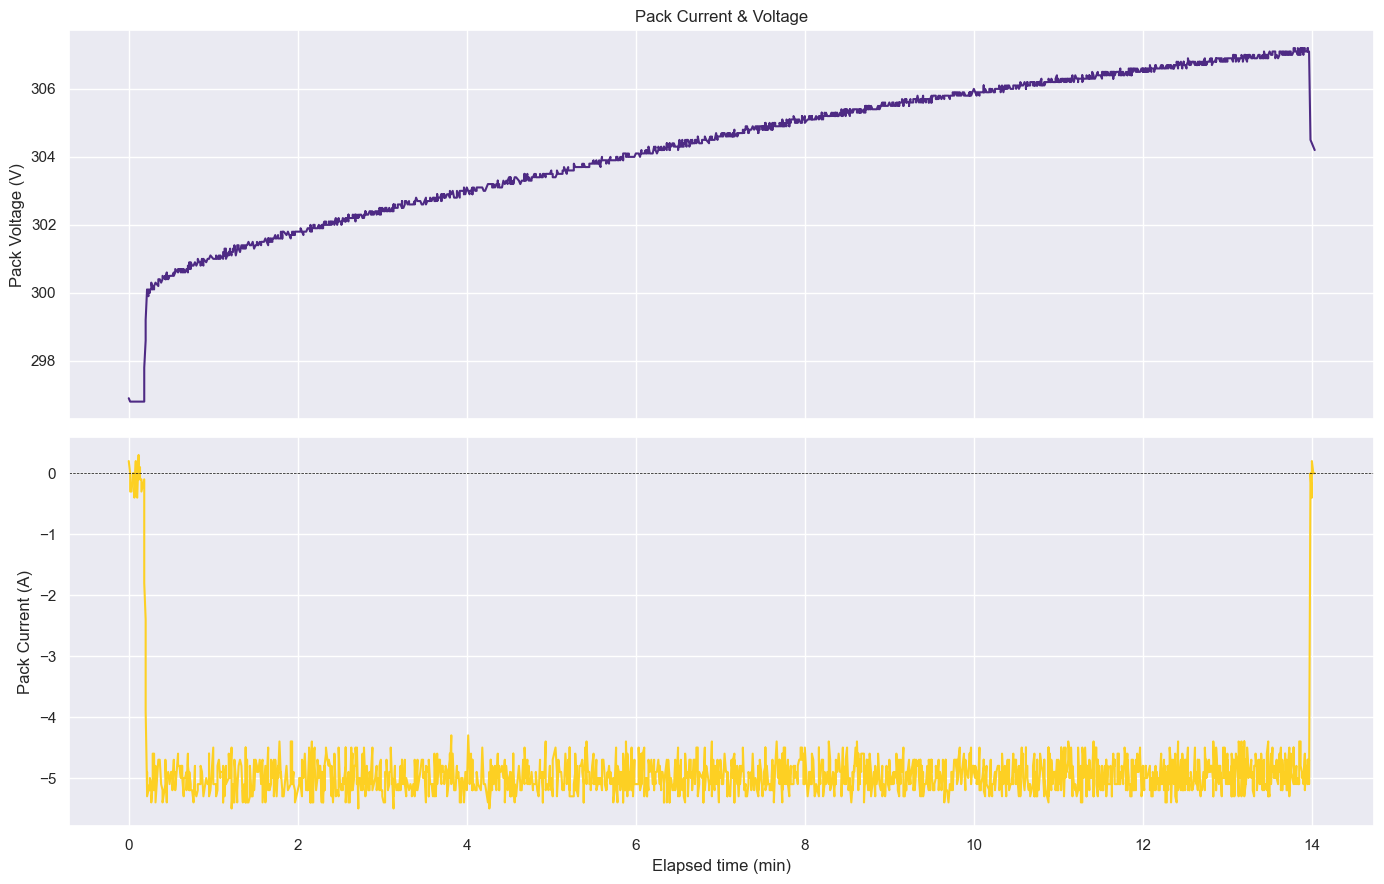

In [97]:
# Pack Voltage & Current Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['elapsed_s'] / 60, df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')

axes[1].plot(df['elapsed_s'] / 60, df['Pack Current'], color = '#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (A)')
axes[1].set_xlabel('Elapsed time (min)')

plt.tight_layout()
plt.show()

C:\Users\randl\AppData\Local\Temp\ipykernel_12008\181269581.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']


Text(0.5, 0, 'Elapsed time (min)')

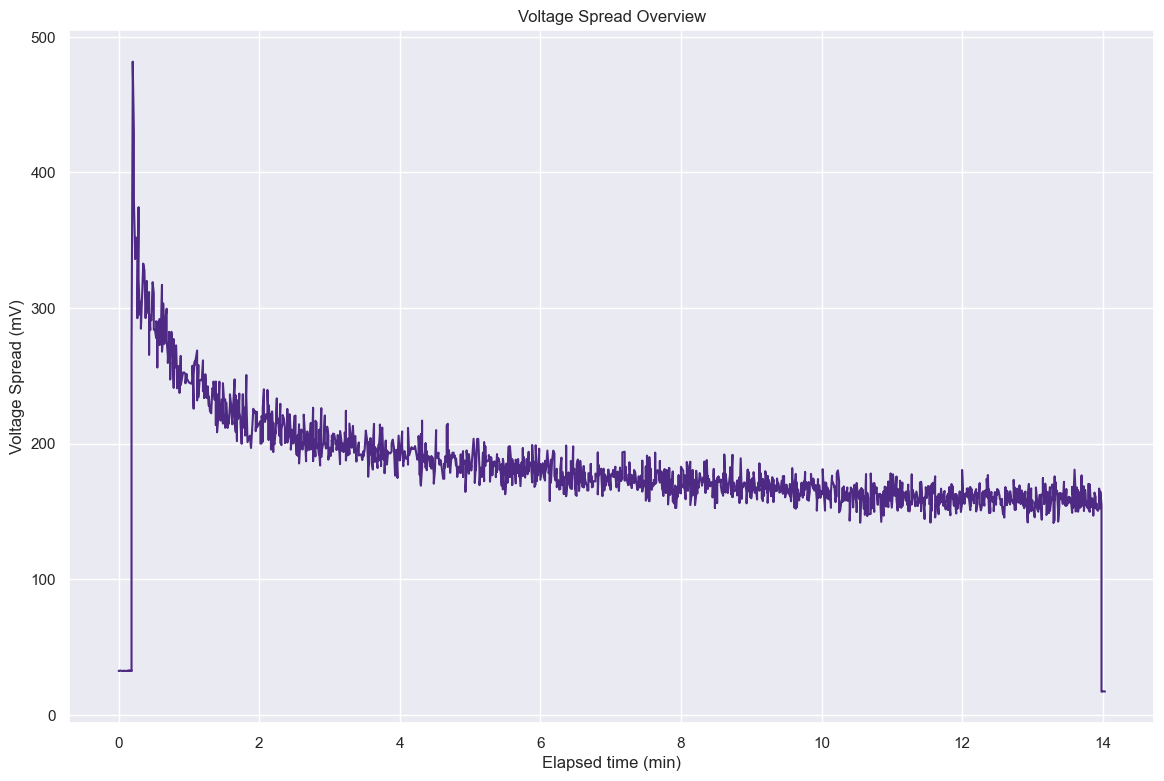

In [98]:
# Spread Over Time
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']

fig,ax = plt.subplots(1, 1, figsize=(14, 9))
ax.plot(df['elapsed_s'] / 60, df['Voltage Spread'] * 1000)
# ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (min)')


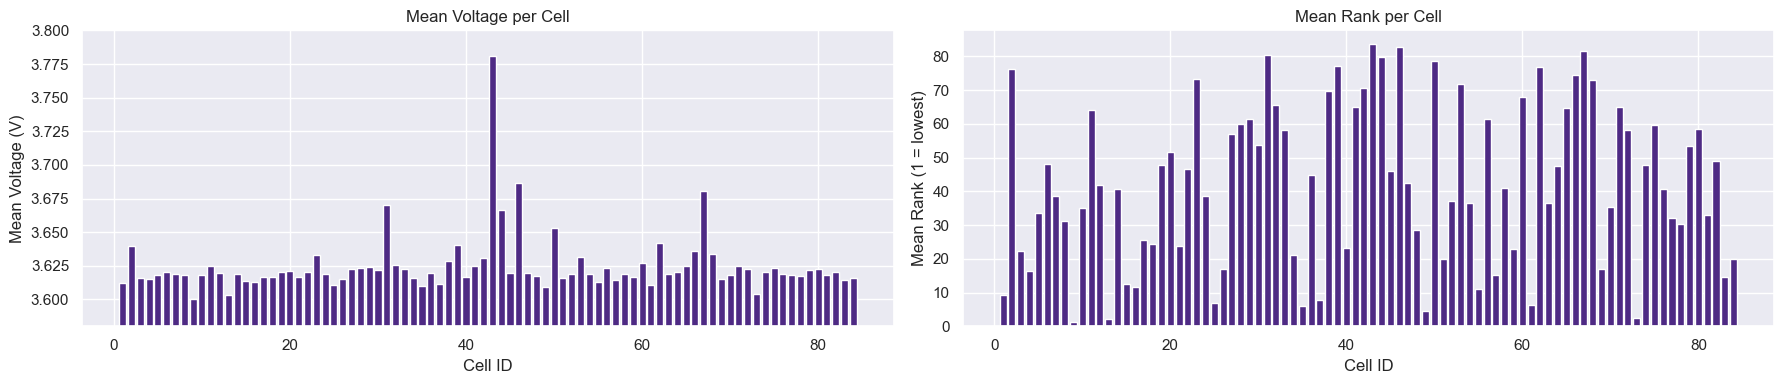

In [99]:
# Mean Voltage And Rank Per Cell
CV_COLS_NUMS = range(1, N_CELLS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

ax1.bar(CV_COLS_NUMS, cell_mean_voltage)
ax1.set_ylim(3.58, 3.8)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CV_COLS_NUMS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

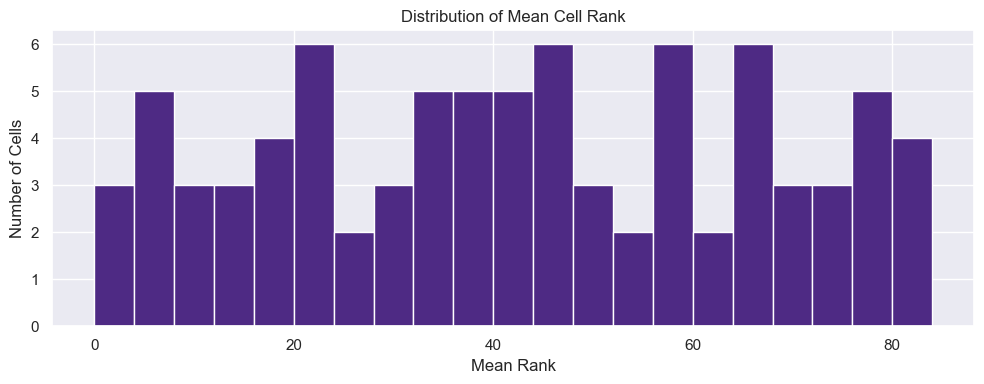

In [100]:
cell_mean_voltage = df[CV_COLS].mean()
cell_mean_rank = df[CV_COLS].rank(axis=1).mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')

plt.tight_layout()
plt.show()

Mean Voltage of Weakest Cells (V)
Cell Voltage 9     3.599978
Cell Voltage 13    3.603605
Cell Voltage 73    3.604000
Cell Voltage 49    3.609060
Cell Voltage 35    3.609671
dtype: float64
Mean Rank of Weakest Cells (1-84)
Cell Voltage 9     1.397067
Cell Voltage 13    2.119258
Cell Voltage 73    2.523520
Cell Voltage 49    4.510515
Cell Voltage 35    5.919203
dtype: float64


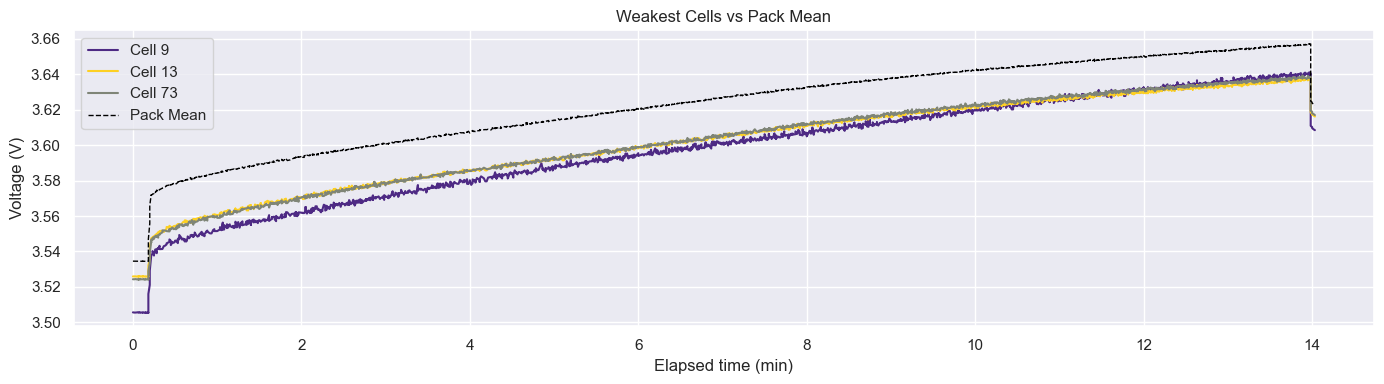

In [101]:
# Weakest Cells VS Pack Mean 
print("Mean Voltage of Weakest Cells (V)")
print(cell_mean_voltage.nsmallest(5))
print("Mean Rank of Weakest Cells (1-84)")
print(cell_mean_rank.nsmallest(5))

pack_mean = df[CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 9'],  label='Cell 9')
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 13'], label='Cell 13')
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 73'], label='Cell 73')
ax.plot(df['elapsed_s'] / 60, pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Weakest Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Voltage (V)')
ax.legend()

plt.tight_layout()
plt.show()